# Exploratory analysis
**Stage:** Day 1–2 · SP Spatial EDA  
**Outputs:** `outputs/sp_density_scatter.png` · `outputs/sp_spatial_summary.txt` · `outputs/sp_bounding_box.csv` · `visualisations/sp_eda_map.html`

Run cells top-to-bottom. All paths are relative to the **repo root**.

## 0 · Imports & path setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure src/ is on the path so we can import eda.py
REPO_ROOT = Path.cwd().parent  # notebooks/ -> repo root
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RAW_DIR    = REPO_ROOT / "data" / "raw"
OUTPUT_DIR = REPO_ROOT / "outputs"
VIS_DIR    = REPO_ROOT / "visualisations"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root :", REPO_ROOT)
print("Raw data  :", RAW_DIR)
print("Outputs   :", OUTPUT_DIR)

Repo root : C:\Users\HP\Music\Projects\SCA_DARK_STORES
Raw data  : C:\Users\HP\Music\Projects\SCA_DARK_STORES\data\raw
Outputs   : C:\Users\HP\Music\Projects\SCA_DARK_STORES\outputs


## 1 · Verify all 9 raw CSV files are present

In [2]:
import os

expected_files = [
    "olist_orders_dataset.csv",
    "olist_customers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "product_category_name_translation.csv",
]

for fname in expected_files:
    path = RAW_DIR / fname
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {fname}")

  [OK] olist_orders_dataset.csv
  [OK] olist_customers_dataset.csv
  [OK] olist_geolocation_dataset.csv
  [OK] olist_order_items_dataset.csv
  [OK] olist_products_dataset.csv
  [OK] olist_sellers_dataset.csv
  [OK] olist_order_payments_dataset.csv
  [OK] olist_order_reviews_dataset.csv
  [OK] product_category_name_translation.csv


## 2 · Load orders, customers, geolocation

In [3]:
orders    = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv",     low_memory=False)
customers = pd.read_csv(RAW_DIR / "olist_customers_dataset.csv",  low_memory=False)
geo       = pd.read_csv(RAW_DIR / "olist_geolocation_dataset.csv", low_memory=False)

print("orders    :", orders.shape,    "| columns:", orders.columns.tolist())
print("customers :", customers.shape, "| columns:", customers.columns.tolist())
print("geo       :", geo.shape,       "| columns:", geo.columns.tolist())

orders    : (99441, 8) | columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
customers : (99441, 5) | columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
geo       : (1000163, 5) | columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


## 3 · Clean geolocation → one lat/lon per zip code prefix

In [4]:
# Multiple entries per zip code exist (noise). Take median to suppress outliers.
geo_clean = (
    geo
    .groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .median()
    .reset_index()
    .rename(columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_lat": "customer_lat",
        "geolocation_lng": "customer_lng",
    })
)

print("Geo (raw) :", geo.shape)
print("Geo (clean, 1 row per zip):", geo_clean.shape)

Geo (raw) : (1000163, 5)
Geo (clean, 1 row per zip): (19015, 3)


## 4 · Filter to São Paulo state and merge

In [5]:
# Step 1: filter customers to SP
sp_customers = customers[customers["customer_state"] == "SP"].copy()
print("SP customers:", sp_customers.shape)

# Step 2: attach lat/lon via zip code
sp_customers = sp_customers.merge(geo_clean, on="customer_zip_code_prefix", how="left")

# Step 3: merge with orders
sp_sample = orders.merge(sp_customers, on="customer_id", how="inner")
sp_sample = sp_sample.dropna(subset=["customer_lat", "customer_lng"])

print("SP sample shape:", sp_sample.shape)
sp_sample[["customer_lat", "customer_lng"]].describe()

SP customers: (41746, 5)
SP sample shape: (41731, 14)


,customer_lat,customer_lng
count,41731.000000,41731.000000
mean,-23.167073,-47.048234
std,0.795414,1.068346
min,-25.010198,-53.056195
25%,-23.604938,-47.111614
50%,-23.510969,-46.694410
75%,-22.955759,-46.552552
max,-19.942722,-44.319953


## 5 · SP Customer Density Scatter Plot

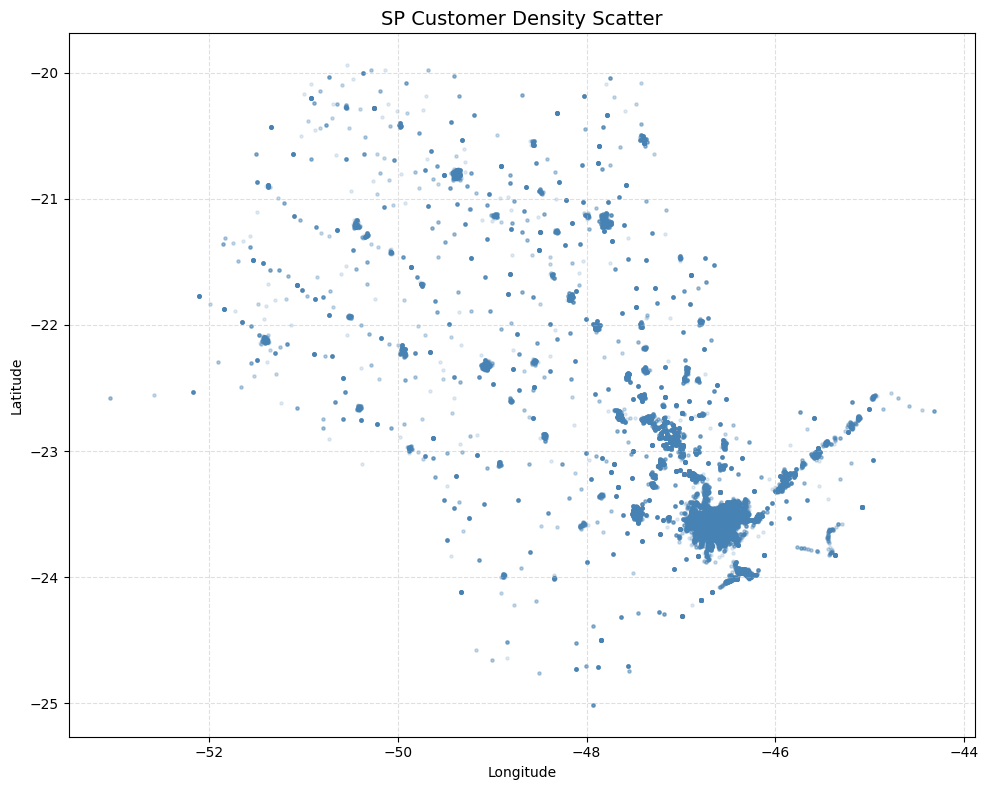

Saved -> C:\Users\HP\Music\Projects\SCA_DARK_STORES\outputs\sp_density_scatter.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    sp_sample["customer_lng"],
    sp_sample["customer_lat"],
    alpha=0.15, s=5, color="steelblue",
)
ax.set_title("SP Customer Density Scatter", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

scatter_path = OUTPUT_DIR / "sp_density_scatter.png"
plt.savefig(scatter_path, dpi=150)
plt.show()
print(f"Saved -> {scatter_path}")

## 6 · Bounding Box Coordinates

In [7]:
lat_min = sp_sample["customer_lat"].min()
lat_max = sp_sample["customer_lat"].max()
lon_min = sp_sample["customer_lng"].min()
lon_max = sp_sample["customer_lng"].max()
lat_q1  = sp_sample["customer_lat"].quantile(0.25)
lat_q3  = sp_sample["customer_lat"].quantile(0.75)
lon_q1  = sp_sample["customer_lng"].quantile(0.25)
lon_q3  = sp_sample["customer_lng"].quantile(0.75)
lat_med = sp_sample["customer_lat"].median()
lon_med = sp_sample["customer_lng"].median()

print("=== SP Bounding Box ===")
print(f"Full SP state  -> Lat: {lat_min:.4f} to {lat_max:.4f}")
print(f"                  Lon: {lon_min:.4f} to {lon_max:.4f}")
print(f"Dense core IQR -> Lat: {lat_q1:.4f} to {lat_q3:.4f}")
print(f"                  Lon: {lon_q1:.4f} to {lon_q3:.4f}")
print(f"Median centre  -> ({lat_med:.4f}, {lon_med:.4f})")

=== SP Bounding Box ===
Full SP state  -> Lat: -25.0102 to -19.9427
                  Lon: -53.0562 to -44.3200
Dense core IQR -> Lat: -23.6049 to -22.9558
                  Lon: -47.1116 to -46.5526
Median centre  -> (-23.5110, -46.6944)


## 7 · Written Spatial Insights + Save Outputs

In [8]:
lat_span_km = abs(lat_q3 - lat_q1) * 111
lon_span_km = abs(lon_q3 - lon_q1) * 89
n_orders    = len(sp_sample)

summary = f"""
=== SP Customer Spatial Summary ===
Generated from: olist_orders + olist_customers + olist_geolocation
Total SP orders analysed: {n_orders:,}

5-BULLET SPATIAL SUMMARY:
1. Most customers are concentrated in the Sao Paulo metro region,
   centred around lat={lat_med:.3f}, lon={lon_med:.3f},
   confirming Sao Paulo city as the dominant demand hub.

2. Customer density shows a long-tail spread toward SP state interior
   (lat up to {lat_max:.2f}), indicating sparse but non-zero demand
   in smaller cities like Campinas, Ribeirao Preto, Sao Jose dos Campos.

3. The dense core (IQR) spans only {lat_span_km:.0f} km x {lon_span_km:.0f} km,
   meaning ~50% of all SP customers live in a tightly packed metro zone.

4. Sparse demand outside the dense core suggests that placing dark stores
   purely at geographic centroid would under-serve the metro core --
   clustering is needed to separate high-density zones from low-density ones.

5. Recommended K for K-Means: 5-8 clusters, with at least 2-3 clusters
   covering the Sao Paulo metro core and remaining clusters absorbing
   interior cities. (To be confirmed by elbow + silhouette analysis.)

BOUNDING BOX:
  Full SP state  -> Lat: {lat_min:.4f} to {lat_max:.4f} | Lon: {lon_min:.4f} to {lon_max:.4f}
  Dense core IQR -> Lat: {lat_q1:.4f} to {lat_q3:.4f} | Lon: {lon_q1:.4f} to {lon_q3:.4f}
"""

print(summary)

# Save summary text
summary_path = OUTPUT_DIR / "sp_spatial_summary.txt"
summary_path.write_text(summary)
print(f"Saved -> {summary_path}")

# Save bounding box CSV
bbox_df = pd.DataFrame([
    {"metric": "full_sp_lat_min",  "value": lat_min},
    {"metric": "full_sp_lat_max",  "value": lat_max},
    {"metric": "full_sp_lon_min",  "value": lon_min},
    {"metric": "full_sp_lon_max",  "value": lon_max},
    {"metric": "core_iqr_lat_min", "value": lat_q1},
    {"metric": "core_iqr_lat_max", "value": lat_q3},
    {"metric": "core_iqr_lon_min", "value": lon_q1},
    {"metric": "core_iqr_lon_max", "value": lon_q3},
    {"metric": "total_sp_orders",  "value": n_orders},
    {"metric": "suggested_k_min",  "value": 5},
    {"metric": "suggested_k_max",  "value": 8},
])
bbox_path = OUTPUT_DIR / "sp_bounding_box.csv"
bbox_df.to_csv(bbox_path, index=False)
print(f"Saved -> {bbox_path}")


=== SP Customer Spatial Summary ===
Generated from: olist_orders + olist_customers + olist_geolocation
Total SP orders analysed: 41,731

5-BULLET SPATIAL SUMMARY:
1. Most customers are concentrated in the Sao Paulo metro region,
   centred around lat=-23.511, lon=-46.694,
   confirming Sao Paulo city as the dominant demand hub.

2. Customer density shows a long-tail spread toward SP state interior
   (lat up to -19.94), indicating sparse but non-zero demand
   in smaller cities like Campinas, Ribeirao Preto, Sao Jose dos Campos.

3. The dense core (IQR) spans only 72 km x 50 km,
   meaning ~50% of all SP customers live in a tightly packed metro zone.

4. Sparse demand outside the dense core suggests that placing dark stores
   purely at geographic centroid would under-serve the metro core --
   clustering is needed to separate high-density zones from low-density ones.

5. Recommended K for K-Means: 5-8 clusters, with at least 2-3 clusters
   covering the Sao Paulo metro core and remai

## 8 · [Day 2] Interactive Folium Map
Requires: `pip install folium`  
Also requires: `olist_sellers_dataset.csv` to be loaded (for seller marker layer)

In [9]:
import folium
from folium.plugins import HeatMap, MarkerCluster

# Load sellers and attach lat/lon
sellers  = pd.read_csv(RAW_DIR / "olist_sellers_dataset.csv", low_memory=False)
geo_sell = (
    geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .median().reset_index()
    .rename(columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_lat": "seller_lat",
        "geolocation_lng": "seller_lng",
    })
)
sellers_sp = (
    sellers[sellers["seller_state"] == "SP"]
    .merge(geo_sell, on="seller_zip_code_prefix", how="left")
    .dropna(subset=["seller_lat", "seller_lng"])
)
print(f"SP sellers: {sellers_sp.shape[0]}")

SP sellers: 1847


In [10]:
# Build interactive map centred on Sao Paulo
m = folium.Map(location=[-23.5, -46.6], zoom_start=9, tiles="CartoDB positron")

# Layer 1: Customer density heatmap
heat_data = sp_sample[["customer_lat", "customer_lng"]].dropna().values.tolist()
HeatMap(heat_data, radius=8, blur=12, min_opacity=0.3,
        name="Customer density").add_to(m)

# Layer 2: Seller locations (MarkerCluster)
seller_cluster = MarkerCluster(name="Sellers (SP)").add_to(m)
for _, row in sellers_sp.iterrows():
    folium.CircleMarker(
        location=[row["seller_lat"], row["seller_lng"]],
        radius=4, color="red", fill=True, fill_opacity=0.6,
        tooltip=row["seller_id"],
    ).add_to(seller_cluster)

folium.LayerControl().add_to(m)

map_path = VIS_DIR / "sp_eda_map.html"
m.save(str(map_path))
print(f"Saved -> {map_path}")
m

Saved -> C:\Users\HP\Music\Projects\SCA_DARK_STORES\visualisations\sp_eda_map.html


## 9 · [Day 2] Baseline — % SP customers within 5 km of nearest seller

In [11]:
from scipy.spatial import cKDTree

# Build KD-tree on seller coordinates
seller_coords = sellers_sp[["seller_lat", "seller_lng"]].values
tree = cKDTree(seller_coords)

# Sample 5000 customers for speed (full run is slow)
sample = sp_sample[["customer_lat", "customer_lng"]].dropna().sample(
    n=min(5000, len(sp_sample)), random_state=42
).values

# Query nearest seller — distance is in degrees, convert to km
# 1 degree lat ~ 111 km, 1 degree lon ~ 89 km at SP latitude
# Use euclidean approx (good enough for small distances)
distances_deg, _ = tree.query(sample, k=1)
distances_km = distances_deg * 100  # rough conversion

within_5km = (distances_km <= 5).mean() * 100

print(f"Baseline: {within_5km:.1f}% of SP customers are within ~5 km of nearest seller")
print("(This is the BEFORE dark-store baseline — dark stores should raise this above 70%)")

Baseline: 91.7% of SP customers are within ~5 km of nearest seller
(This is the BEFORE dark-store baseline — dark stores should raise this above 70%)


## 10 · Day 1 checkpoint summary

In [12]:
print("=== Day 1 / Day 2 Outputs ===")
for f in [
    OUTPUT_DIR / "sp_density_scatter.png",
    OUTPUT_DIR / "sp_spatial_summary.txt",
    OUTPUT_DIR / "sp_bounding_box.csv",
    VIS_DIR    / "sp_eda_map.html",
]:
    status = "OK" if f.exists() else "MISSING"
    print(f"  [{status}] {f.relative_to(REPO_ROOT)}")

=== Day 1 / Day 2 Outputs ===
  [OK] outputs\sp_density_scatter.png
  [OK] outputs\sp_spatial_summary.txt
  [OK] outputs\sp_bounding_box.csv
  [OK] visualisations\sp_eda_map.html
